In [1]:
# Suppress warnings (for clean teaching output)
import warnings
warnings.filterwarnings('ignore')

# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

In [4]:
# Load dataset
try:
    df = pd.read_csv(r"C:\Users\lokesh\OneDrive\Desktop\PDA\McDonalds_Financial_Statements.csv")
    print("Dataset loaded successfully")
except FileNotFoundError:
    print("Check file path!")

Dataset loaded successfully


In [5]:
print(df.shape)


(21, 17)


In [6]:
# View data
df.head()

,Year,Market cap ($B),Revenue ($B),Earnings ($B),P/E ratio,P/S ratio,P/B ratio,Operating Margin (%),EPS ($),Shares Outstanding ($B),Cash on Hand ($B),Dividend Yield (%),Dividend (stock split adjusted) ($),Net assets ($B),Total assets ($B),Total debt ($B),Total liabilities ($B)
0,2022,193.01,23.18,7.82,31.3,8.33,-32.2,33.76,8.42,0.73,2.58,2.15,5.66,-6.01,50.43,48.03,56.43
1,2021,200.31,23.22,9.12,26.5,8.63,-43.5,39.31,10.11,0.74,4.70,1.96,5.25,-4.61,53.60,48.64,58.20
2,2020,159.88,19.20,6.14,33.8,8.32,-20.4,31.97,6.35,0.74,3.44,2.35,5.04,-7.83,52.62,48.51,60.45
3,2019,147.47,21.28,8.01,24.8,6.93,-18.0,38.04,7.98,0.74,0.89,2.39,4.73,-8.22,47.51,46.87,55.72
4,2018,136.21,21.02,7.81,23.2,6.48,-21.8,37.17,7.65,0.76,0.86,2.36,4.19,-6.26,32.81,31.07,39.06


In [7]:
# Basic info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 17 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Year                                 21 non-null     int64  
 1   Market cap ($B)                      21 non-null     float64
 2   Revenue ($B)                         21 non-null     float64
 3   Earnings ($B)                        21 non-null     float64
 4   P/E ratio                            21 non-null     float64
 5   P/S ratio                            21 non-null     float64
 6   P/B ratio                            21 non-null     float64
 7   Operating Margin (%)                 21 non-null     float64
 8   EPS ($)                              21 non-null     float64
 9   Shares Outstanding ($B)              21 non-null     float64
 10  Cash on Hand ($B)                    21 non-null     float64
 11  Dividend Yield (%)                

In [8]:
    # Summary statistics
print(df.describe(include='all'))

              Year  Market cap ($B)  Revenue ($B)  Earnings ($B)  P/E ratio  \
count    21.000000        21.000000     21.000000      21.000000  21.000000   
mean   2012.000000        96.824286     22.706190       6.214762  21.661905   
std       6.204837        50.396346      3.398316       2.226166   5.541974   
min    2002.000000        20.390000     15.400000       1.660000  15.000000   
25%    2007.000000        67.220000     20.810000       3.880000  16.500000   
50%    2012.000000        90.220000     22.820000       6.860000  21.400000   
75%    2017.000000       136.210000     24.620000       8.010000  24.800000   
max    2022.000000       200.310000     28.100000       9.120000  33.800000   

       P/S ratio  P/B ratio  Operating Margin (%)    EPS ($)  \
count  21.000000  21.000000             21.000000  21.000000   
mean    4.234762  -7.100000             26.889048   4.852857   
std     2.266896  19.356029              8.355580   2.507501   
min     1.320000 -45.900000     

In [9]:
# Check missing values
df.isnull().sum()

Year                                   0
Market cap ($B)                        0
Revenue ($B)                           0
Earnings ($B)                          0
P/E ratio                              0
P/S ratio                              0
P/B ratio                              0
Operating Margin (%)                   0
EPS ($)                                0
Shares Outstanding ($B)                0
Cash on Hand ($B)                      0
Dividend Yield (%)                     0
Dividend (stock split adjusted) ($)    0
Net assets ($B)                        0
Total assets ($B)                      0
Total debt ($B)                        0
Total liabilities ($B)                 0
dtype: int64

In [10]:
# Fill or drop missing values
df.ffill(inplace=True)

In [11]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [20]:
# Convert date column if exists
df['Date'] = pd.to_datetime(df['Date'])

KeyError: 'Date'

In [13]:
df.columns = df.columns.str.strip()   # remove spaces
print(df.columns)

Index(['Year', 'Market cap ($B)', 'Revenue ($B)', 'Earnings ($B)', 'P/E ratio',
       'P/S ratio', 'P/B ratio', 'Operating Margin (%)', 'EPS ($)',
       'Shares Outstanding ($B)', 'Cash on Hand ($B)', 'Dividend Yield (%)',
       'Dividend (stock split adjusted) ($)', 'Net assets ($B)',
       'Total assets ($B)', 'Total debt ($B)', 'Total liabilities ($B)'],
      dtype='object')


In [14]:
df.columns = (
    df.columns
    .str.replace(r"\(.*?\)", "", regex=True)
    .str.strip()
    .str.replace(" ", "_")
    .str.lower()
)
print(df.columns)

Index(['year', 'market_cap', 'revenue', 'earnings', 'p/e_ratio', 'p/s_ratio',
       'p/b_ratio', 'operating_margin', 'eps', 'shares_outstanding',
       'cash_on_hand', 'dividend_yield', 'dividend', 'net_assets',
       'total_assets', 'total_debt', 'total_liabilities'],
      dtype='object')


In [15]:
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

In [16]:
# Example: Create Profit Margin
df['Profit_Margin'] = np.where(
    df['revenue'] != 0,
    df['earnings'] / df['revenue'],
    0
)

In [17]:

# Normalize a column
df['Revenue_Scaled'] = (df['revenue'] - df['revenue'].mean()) / df['revenue'].std()

In [19]:
#Rename columns
df.rename(columns={'Net Income': 'Net_Income'}, inplace=True)

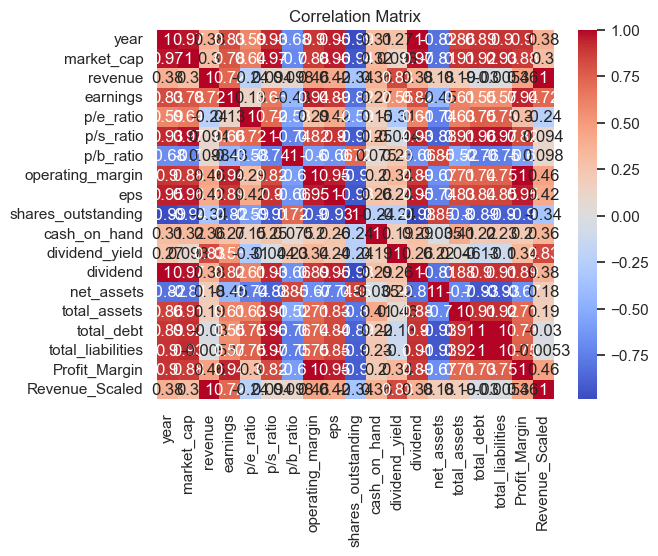

In [21]:
# Correlation matrix
corr = df.corr()

plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

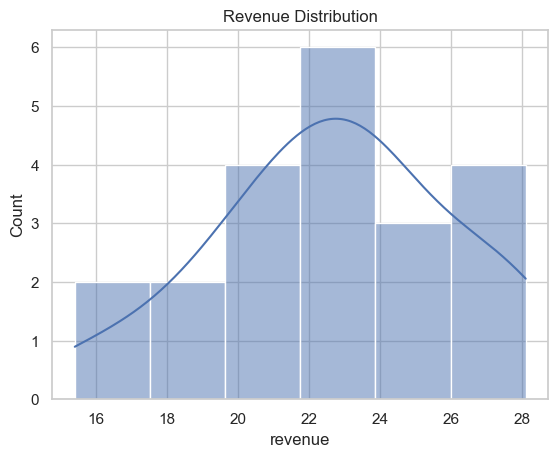

In [22]:
sns.histplot(df['revenue'], kde=True)
plt.title("Revenue Distribution")
plt.show()

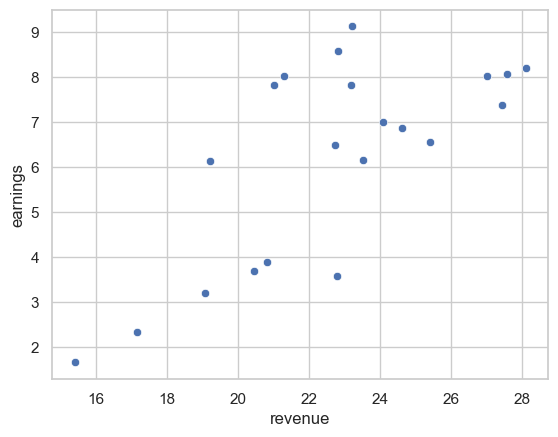

In [23]:
sns.scatterplot(data=df, x='revenue', y='earnings')
plt.show()

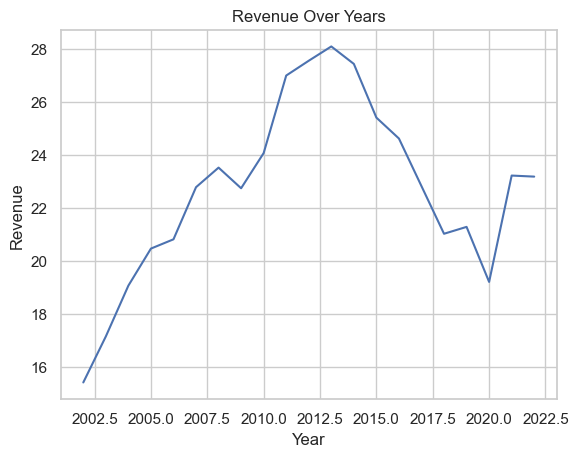

In [24]:
plt.plot(df['year'], df['revenue'])
plt.title("Revenue Over Years")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.show()

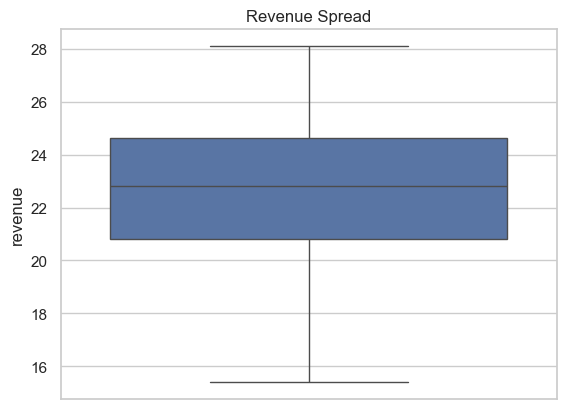

In [25]:
sns.boxplot(y=df['revenue'])
plt.title("Revenue Spread")
plt.show()

In [26]:
Q1 = df['revenue'].quantile(0.25)
Q3 = df['revenue'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['revenue'] >= Q1 - 1.5*IQR) & (df['revenue'] <= Q3 + 1.5*IQR)]

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

# Evaluate
print("R2 Score:", r2_score(y_test, pred))

NameError: name 'X_train' is not defined

In [28]:
# Create binary target (1 = High Earnings, 0 = Low Earnings)
df['high_earnings'] = np.where(
    df['earnings'] > df['earnings'].median(),
    1,
    0
)

In [29]:
# Select Features
X = df[['revenue', 'market_cap']]
y = df['high_earnings']